# Домашнее задание: Ансамблевые методы

### Описание
В этом задании вы примените на практике три ключевых алгоритма ансамблирования:
Для решения задания необходимо реализовать свои классы Случайного леса и IsolationForest

1.  **RandomForestClassifier** для задачи классификации и анализа устойчивости к переобучению.
2.  **RandomForestRegressor** для нетривиальной задачи восстановления пропущенных данных.
3.  **IsolationForest** для поиска аномалий в дан

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import ExtraTreesRegressor
from scipy.stats import mode
# Фиксация генератора случайных чисел для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

In [7]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

###  Ваша реализация Случайного Леса для классификации

### Задача: Реализовать бэггинг (Bootstrap Aggregating) над решающими деревьями

###  Ваша реализация Случайного Леса для регрессии

### Принцип тот же, но агрегация через усреднение

In [19]:
class MyRandomForestClassifier:
    """
    Ваша реализация Случайного Леса для классификации.

    Задача: Реализовать бэггинг (Bootstrap Aggregating) над решающими деревьями.
    """
    def __init__(self, n_estimators=10, max_depth=None, max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.random_state = random_state
        self.trees = [] # Сюда будем складывать обученные деревья

    def fit(self, X, y):
        """
        Обучение ансамбля.
        1. Создайте n_estimators деревьев.
        2. Для каждого дерева создайте бутстрап-выборку (X_boot, y_boot).
        3. Обучите дерево на этой выборке.
        """
        self.trees = []
        n_samples = X.shape[0]
        np.random.seed(self.random_state)

        for i in range(self.n_estimators):
            # Подсказка: используйте np.random.choice для генерации индексов
            indices = np.random.choice(n_samples, size=n_samples)

            X_boot, y_boot = X[indices], y[indices]

            # Не забудьте передать max_depth и max_features
            tree = DecisionTreeClassifier(max_depth=self.max_depth, max_features=self.max_features)

            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

        return self

    def predict(self, X):
        """
        Предсказание классов.
        1. Получите предсказания от всех деревьев.
        2. Для каждого объекта выберите класс, за который проголосовало большинство.
        """
        # Сюда будем собирать предсказания всех деревьев: (n_samples, n_estimators)
        all_preds = np.zeros((X.shape[0], self.n_estimators))

        for i, tree in enumerate(self.trees):
            all_preds[:, i] = tree.predict(X)

        # Подсказка: используйте scipy.stats.mode(all_preds, axis=1)
        result = mode(all_preds, axis=1)

        return result.mode.ravel()



In [23]:

class MyRandomForestRegressor:
    """
    Ваша реализация Случайного Леса для регрессии.
    Принцип тот же, но агрегация через усреднение.
    """

    def __init__(self, n_estimators=10, max_depth=None, max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        np.random.seed(self.random_state)

        for i in range(self.n_estimators):
            indices = np.random.choice(n_samples, size=n_samples)
            X_boot, y_boot = X[indices], y[indices]

            tree = DecisionTreeRegressor(max_depth=self.max_depth, max_features=self.max_features)

            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

        return self

    def predict(self, X):
        """
        Предсказание значений.
        Агрегация: Среднее арифметическое предсказаний всех деревьев.
        """
        # Массив для сбора ответов
        all_preds = np.zeros((X.shape[0], self.n_estimators))

        for i, tree in enumerate(self.trees):
            all_preds[:, i] = tree.predict(X)

        mean_preds = all_preds.mean(axis=1)

        return mean_preds

###  Упрощенная версия Isolation Forest

### Мы строим случайные деревья (ExtraTrees).

Аномалии - это точки, которые попадают в листья на маленькой глубине (их легко изолировать)

In [ ]:
from sklearn.tree import ExtraTreeRegressor


class MySimplifiedIsolationForest:
    """
    Упрощенная версия Isolation Forest.
    Идея: Мы строим случайные деревья (ExtraTrees)
    Аномалии — это точки, которые попадают в листья на маленькой глубине (их легко изолировать)
    """

    def __init__(self, n_estimators=10, max_samples=100, random_state=42):
        self.n_estimators = n_estimators
        self.max_samples = max_samples # Размер подвыборки для каждого дерева
        self.random_state = random_state
        self.trees = []

    def fit(self, X):
        """
        В Isolation Forest мы не используем y (обучение без учителя).
        """
        self.trees = []
        n_samples = X.shape[0]
        np.random.seed(self.random_state)

        for i in range(self.n_estimators):
            indices = np.random.choice(n_samples, size=self.max_samples, replace=False)
            X_sub = X[indices]

            # Используем ExtraTreeRegressor, который делает случайные сплиты
            # Мы будем "предсказывать" просто случайные значения, нам важна только структура дерева
            tree = ExtraTreeRegressor(max_depth=None, max_features=1)

            # Фиктивный y, он не важен для построения структуры в данном упрощении
            tree.fit(X_sub, np.zeros(len(X_sub)))

            self.trees.append(tree)
        return self

    def decision_function(self, X):
        """
        Возвращает меру аномальности.
        В реальном IF это длина пути. Здесь мы будем аппроксимировать это через
        глубину листа, в который попал объект.
        Чем меньше глубина -> тем проще изолировать -> тем больше это аномалия.
        """
        depths = np.zeros((X.shape[0], self.n_estimators))

        for i, tree in enumerate(self.trees):
            # apply возвращает индекс листа, в который попал объект
            leaf_indices = tree.apply(X)

            # В sklearn глубина хранится в tree.tree_.n_node_samples или можно вычислить
            # Для упрощения задачи: можно использовать decision_path
            node_indicator = tree.decision_path(X)
            n_samples = X.shape[0]

            # Сумма единиц в строке матрицы путей = глубина листа
            depths[:, i] = np.array(node_indicator.getnnz(axis=1))

        # Усредняем глубину по всем деревьям
        avg_depth = depths.mean(axis=1)

        # Инвертируем: чем меньше глубина, тем выше score (аномалия)
        # Это упрощенная формула, не совсем как в оригинальной статье, но передает суть
        score = -avg_depth
        return score

    def predict(self, X, threshold=-10):
        """
        Возвращает -1 для аномалий и 1 для нормы.
        """
        scores = self.decision_function(X)
        return np.where(scores > threshold, -1, 1)

## Задание 1. Классификация: Лес против Дерева

Цель: Экспериментально подтвердить, что увеличение количества деревьев в лесу не приводит к переобучению и повышает стабильность.

Используется датасет Breast Cancer (бинарная классификация рака груди)

In [10]:
# 1. Загрузка данных
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

# 2. Обучение одиночного дерева (baseline)
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

print(f"Точность одиночного дерева: {dt_acc:.4f}")

Точность одиночного дерева: 0.9415


In [20]:
# 3. Эксперимент с количеством деревьев
# Задача: Обучить RandomForestClassifier в цикле с n_estimators от 1 до 100
# Сохранить accuracy на тестовой выборке в список rf_scores

n_estimators_list = range(1, 101)
rf_scores = []

for n in n_estimators_list:
    # ВАШ КОД ЗДЕСЬ: инициализация и обучение RandomForestClassifier
    # Используйте random_state=RANDOM_STATE и n_jobs=-1 для ускорения
    rf = MyRandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)

    acc = accuracy_score(y_test, rf.predict(X_test))
    rf_scores.append(acc)


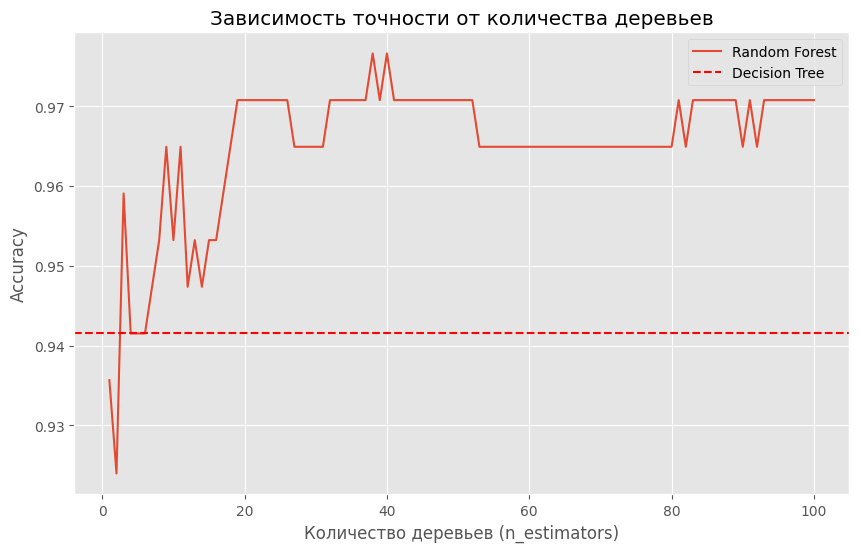

In [21]:
# Визуализация
plt.plot(n_estimators_list, rf_scores, label='Random Forest')
plt.axhline(dt_acc, color='r', linestyle='--', label='Decision Tree')
plt.xlabel('Количество деревьев (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Зависимость точности от количества деревьев')
plt.legend()
plt.show()

In [22]:
# ТЕСТЫ ДЛЯ ЗАДАНИЯ 1
assert len(rf_scores) == 100, "Список rf_scores должен содержать 100 значений"
assert rf_scores[-1] > dt_acc, "В данном случае Лес должен работать лучше одиночного дерева"

## Задание 2. Инженерное применение: Импутация данных

Цель: Использовать регрессионный лес для восстановления пропущенных значений

Мы намеренно удалим часть данных и попробуем их восстановить

In [14]:
# Подготовка данных
# Генерируем данные, где признаки коррелируют друг с другом
X_gen, y_gen = make_blobs(n_samples=1000, centers=1, n_features=5, random_state=RANDOM_STATE)
df = pd.DataFrame(X_gen, columns=[f'Feat_{i}' for i in range(5)])

# Искусственно создаем пропуски в колонке Feat_0
n_missing = 200
missing_indices = np.random.choice(df.index, n_missing, replace=False)

# Сохраняем истинные значения для проверки
true_values = df.loc[missing_indices, 'Feat_0'].copy()

# Удаляем значения
df.loc[missing_indices, 'Feat_0'] = np.nan

print(f"Количество пропусков: {df['Feat_0'].isna().sum()}")

Количество пропусков: 200


In [132]:
# Реализация восстановления

# 1. Разделите датафрейм df на две части:
# train_df: строки, где Feat_0 НЕ пустой
# predict_df: строки, где Feat_0 пустой (NaN)

# ВАШ КОД ЗДЕСЬ
train_df = df[df['Feat_0'].notnull()]
predict_df = df[df['Feat_0'].isnull()]

# 2. Сформируйте признаки (X) и целевую переменную (y)
# X: все колонки, кроме Feat_0
# y: колонка Feat_0

# ВАШ КОД ЗДЕСЬ
X_train_imp = train_df.drop('Feat_0', axis=1)
y_train_imp = train_df['Feat_0']
X_predict_imp = predict_df.drop('Feat_0', axis=1)

# 3. Обучите RandomForestRegressor
rf_imputer = RandomForestRegressor(n_estimators=32, random_state=RANDOM_STATE, max_depth=7, max_features=2, n_jobs=-1, min_samples_split=2, min_samples_leaf=300)
rf_imputer.fit(X_train_imp, y_train_imp)

# 4. Предскажите пропущенные значения
predicted_values = rf_imputer.predict(X_predict_imp)

# Сравнение с простым заполнением средним
mean_fill_values = [train_df['Feat_0'].mean()] * n_missing

mse_rf = mean_squared_error(true_values, predicted_values)
mse_mean = mean_squared_error(true_values, mean_fill_values)

print(f"MSE (Random Forest): {mse_rf:.4f}")
print(f"MSE (Mean Fill):     {mse_mean:.4f}")

MSE (Random Forest): 0.9427
MSE (Mean Fill):     0.9431


In [131]:
# ТЕСТЫ ДЛЯ ЗАДАНИЯ 2
assert len(train_df) == 800, "Размер обучающей выборки неверен"
assert len(predict_df) == 200, "Размер выборки для предсказания неверен"
assert mse_rf < mse_mean, "Модель должна работать лучше, чем заполнение средним"
print("Тест пройден: Импутация выполнена успешно.")

Тест пройден: Импутация выполнена успешно.


## Задание 3. Поиск аномалий

**Цель:** Найти выбросы в данных, используя `IsolationForest`

In [133]:
# Генерация данных
# 300 нормальных точек и 20 аномалий
X_normal, _ = make_blobs(n_samples=300, centers=1, cluster_std=1.0, center_box=(0, 0), random_state=RANDOM_STATE)
X_anomalies = np.random.uniform(low=-10, high=10, size=(20, 2))
X_final = np.vstack([X_normal, X_anomalies])

In [134]:

# ВАШ КОД ЗДЕСЬ:
# 1. Инициализируйте IsolationForest. Установите contamination=0.06 (примерная доля выбросов)
iso_forest = IsolationForest(contamination=0.06, random_state=RANDOM_STATE)

# 2. Обучите модель и получите предсказания (fit_predict)
# Результат должен содержать: 1 (норма) и -1 (аномалия)
preds = iso_forest.fit_predict(X_final)


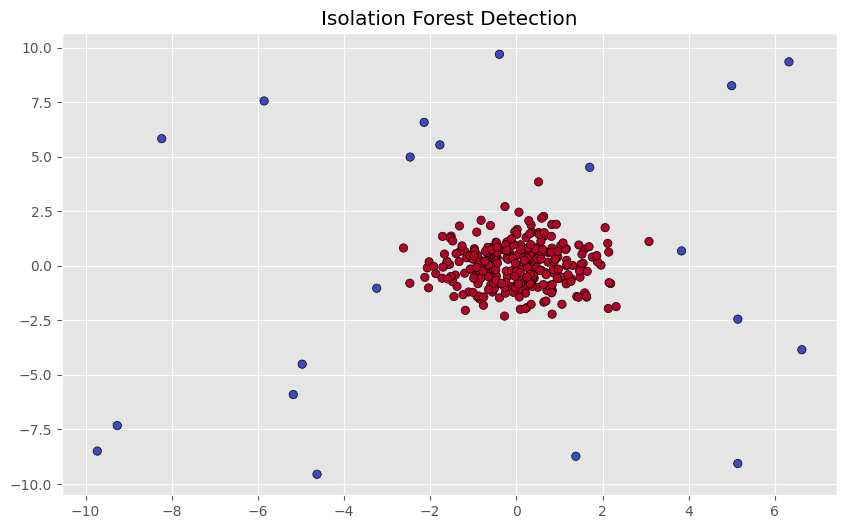

In [135]:

# Визуализация
plt.scatter(X_final[:, 0], X_final[:, 1], c=preds, cmap='coolwarm', edgecolor='k')
plt.title('Isolation Forest Detection')
plt.show()

In [136]:
# ТЕСТЫ ДЛЯ ЗАДАНИЯ 3
n_detected_anomalies = np.sum(preds == -1)
print(f"Обнаружено аномалий: {n_detected_anomalies}")

# Проверяем, что модель нашла хотя бы часть аномалий (мы знаем, что их 20)
assert 15 <= n_detected_anomalies <= 25, "Количество найденных аномалий должно быть близко к истинному (20)"

Обнаружено аномалий: 20
